### Import

In [4]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns
sns.set()
import yfinance as yf
import requests
from tqdm import tqdm
from datetime import datetime
import pickle
import scipy.optimize as sco

# VXX를 활용한 Tail Risk Hedging 전략 설명글

### Tail Risk Hedging이란? ### 

- 2008년 글로벌 금융위기 (S&P500 기준 약 57% 폭락), 코로나 팬데믹 ((S&P500 기준 약 33% 폭락))과 같은 금융시장의 블랙스완/팻테일 이벤트가 발생했을 때 손실을 대비하는 디펜시브 전략

- 위기 상황일 때는 큰 수익를 얻지만, 평소에는 손실 또는 유지

### 가장 잘 알려진 Tail Risk Hedging 전략과 한계점? ###

- 시장 폭락 시 풋옵션을 매수하여 수익을 추구하는 전략, 

- 한계점 : 포트폴리오 보험 차원에서 풋옵션 매수 전략을 포폴의 5% 규모로 편입하였을 때 지속적인 프리미엄 지출 및 풋옵션 매수가 내가격(AT THE MONEY) 상태가 될 때 체결이 잘 되지 않는 문제점이 존재, 따라서 지속적으로 풋옵션 매수 전략을 가지고 갈 수 없음.   

### CUSTOM Tail Risk Hedging 전략 ###

- 투자 자산 및 설명/특징: 

  - 투자 자산 : VXX 

  - 설명 : VIX 근월/차월 선물을 매일 롤오버하는 과정에서 발생하는 총수익을 발행사가 약속해주는 상장 채권(ETN), 위기 시 급등하여 수익 추구 가능 But 평상시에는 롤오버 구조적 손실이 발생하는 단기 테일 헤지 전용 상품

  - 특징 : VIX 선물 Curve는 일반적으로 안정적인 시장 상황에서는 콘탱고, 금융위기 같은 불안정한 시장 상황에서는 백워데이션 구조를 보임. 따라서 대부분은 콘탱고 상황이므로 VXX 상품 내 롤오버 시 지속적인 손실이 누적, 따라서 장기보유는 절대 금지이며, 위기 상황일 때만 보험용으로 단기 투자해야하는 상품

- 투자 시그널 생성 방식
  
  - 데이터 : VIX지수(S&P500 옵션의 향후 30일 내재변동성 지표), VIX3M지수(S&P500 옵션의 향후 90일 내재변동성 지표)
  
  - 시그널 계산 방식 : VIX / VIX3M > 1.1 이면 Signal On, VIX/VIX3M <= 1.1 이면 Signal Off
  
  - 시그널 해석 : 정상적인 상황에서는 단기(30일) 내재변동성보다 장기(90일) 내재변동성이 더 크고, 단기변동성 > 장기변동성인 상황은 일반적으로 금융위기와 같은 블랙스완 이벤트 발생 시 나타남. 따라서 VIX / VIX3M이 1.1 이상이면 30일 단기 변동성이 90일 단기 변동성보다 크다는 의미이므로 주식 시장에 불안감 도래 가능성 상승
  
- 수익 구조
  
  - VIX / VIX3M > 1.1 이면 옵션 시장에서는 단기 내재변동성이 장기 내재변동성보다 크다는 의미. 이를 VIX 선물에 대입하면, VIX 선물 근월물이 차월물보다 비싸지는 백워데이션 가능성이 높아짐. 따라서 매일 선물 롤오버를 진행하는 VXX 특성 상 백워데이션 발생 시 수익이 발생함.
  
  - 결론적으로 옵션 시장의 변동성 구조를 VIX/VIX3M 비율로 측정한 후, 1.1이 넘는다면 -> 위기 상황으로 판단 -> VIX 선물 구조에 백워데이션이 생길 가능성이 높다고 판단 -> 근월/차월 롤오버를 매일 진행하는 VXX 상품을 통해 백워데이션 롤오버 수익를 수취




### S&P500 지수와 VIX(30일 미래 변동성 심리 지수)의 역사적 상관관계

[*********************100%***********************]  2 of 2 completed


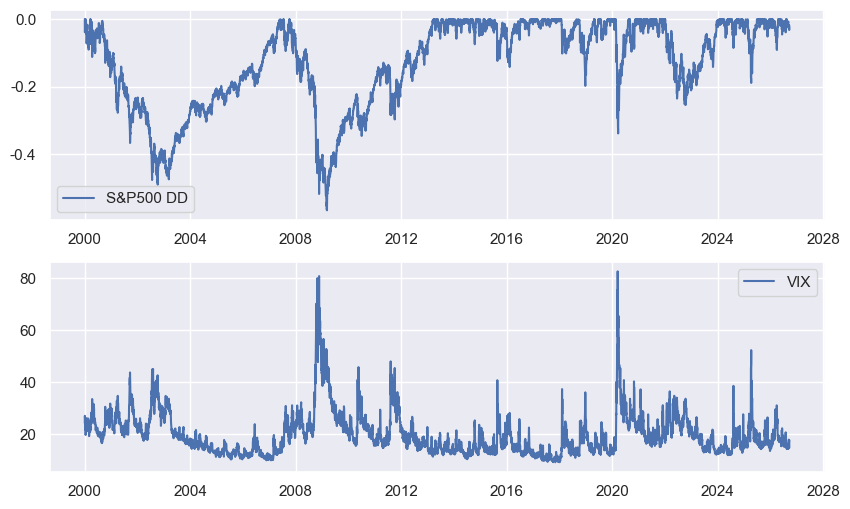

In [4]:
# S&P500, VIX 티커
ticker = ['^GSPC','^VIX']

# 데이터 다운로드 및 종가 필터링
sp_vix = yf.download(ticker, start='2000-01-01', end='2026-09-21', auto_adjust=True)
sp_vix = sp_vix['Close'] 
sp_500 = sp_vix['^GSPC']
vix = sp_vix['^VIX']

# S&P500의 DD/MDD
sp_dd = (sp_500 / sp_500.cummax()) - 1
sp_mdd = sp_dd.min

# S&P500 DrawDown 과 VIX 역사적 Plot
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(sp_dd, label='S&P500 DD')
plt.legend()
plt.subplot(2,1,2)
plt.plot(vix, label='VIX')
plt.legend()
plt.show()

### S&P500 지수와 S&P500 일간 주간 분산 차 비교

[*********************100%***********************]  1 of 1 completed


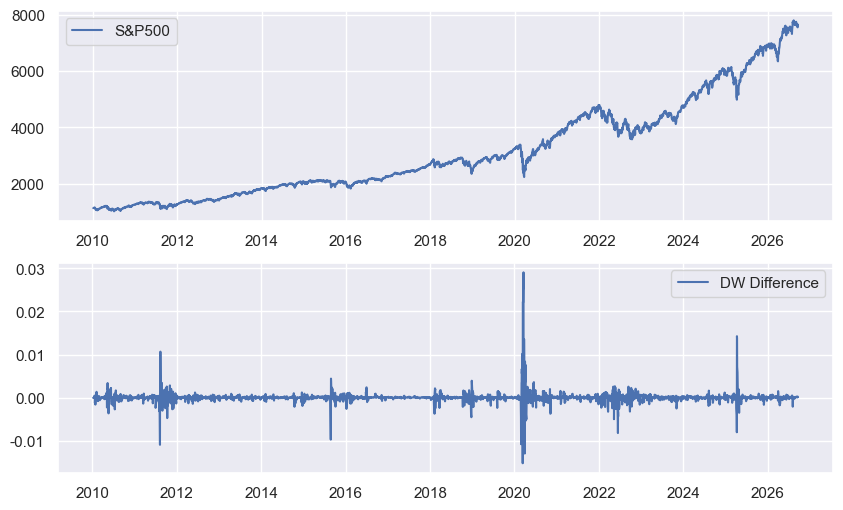

In [5]:
# S&P500 가격 데이터
sp_500 = yf.download('^GSPC', start='2010-01-01', end='2026-09-21', auto_adjust=True)
sp_500 = sp_500['Close']

# S&P500 수익률
sp_rets = sp_500.pct_change().fillna(0)

# S&P500 일간 분산 
sp_dv = (sp_rets ** 2).rolling(5).sum()
sp_wv = (sp_rets.rolling(5).sum()) ** 2

# 시각화
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(sp_500, label='S&P500')
plt.legend()
plt.subplot(2,1,2)
plt.plot((sp_dv - sp_wv), label='DW Difference')
plt.legend()
plt.show()

### S&P500 개별 종목과 일간 주간 분산 차 비교

[*********************100%***********************]  1 of 1 completed


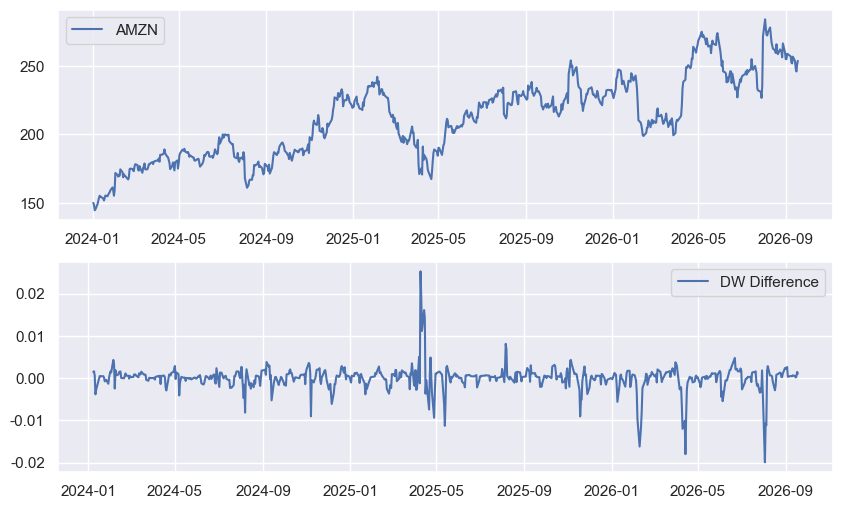

In [6]:
# 종목 티커
ticker = 'AMZN'

# 종목 가격 데이터
price = yf.download(ticker, start='2024-01-01', end='2026-09-21', auto_adjust=True)
price = price['Close']

# 종목 수익률
rets = price.pct_change().fillna(0)

# 종목 일간 분산 
dv = (rets ** 2).rolling(5).sum()
wv = (rets.rolling(5).sum()) ** 2
dwd = dv - wv

# 시각화
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(price, label=ticker)
plt.legend()
plt.subplot(2,1,2)
plt.plot(dwd, label='DW Difference')
plt.legend()
plt.show()

### VIX/VIX3M Ratio

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


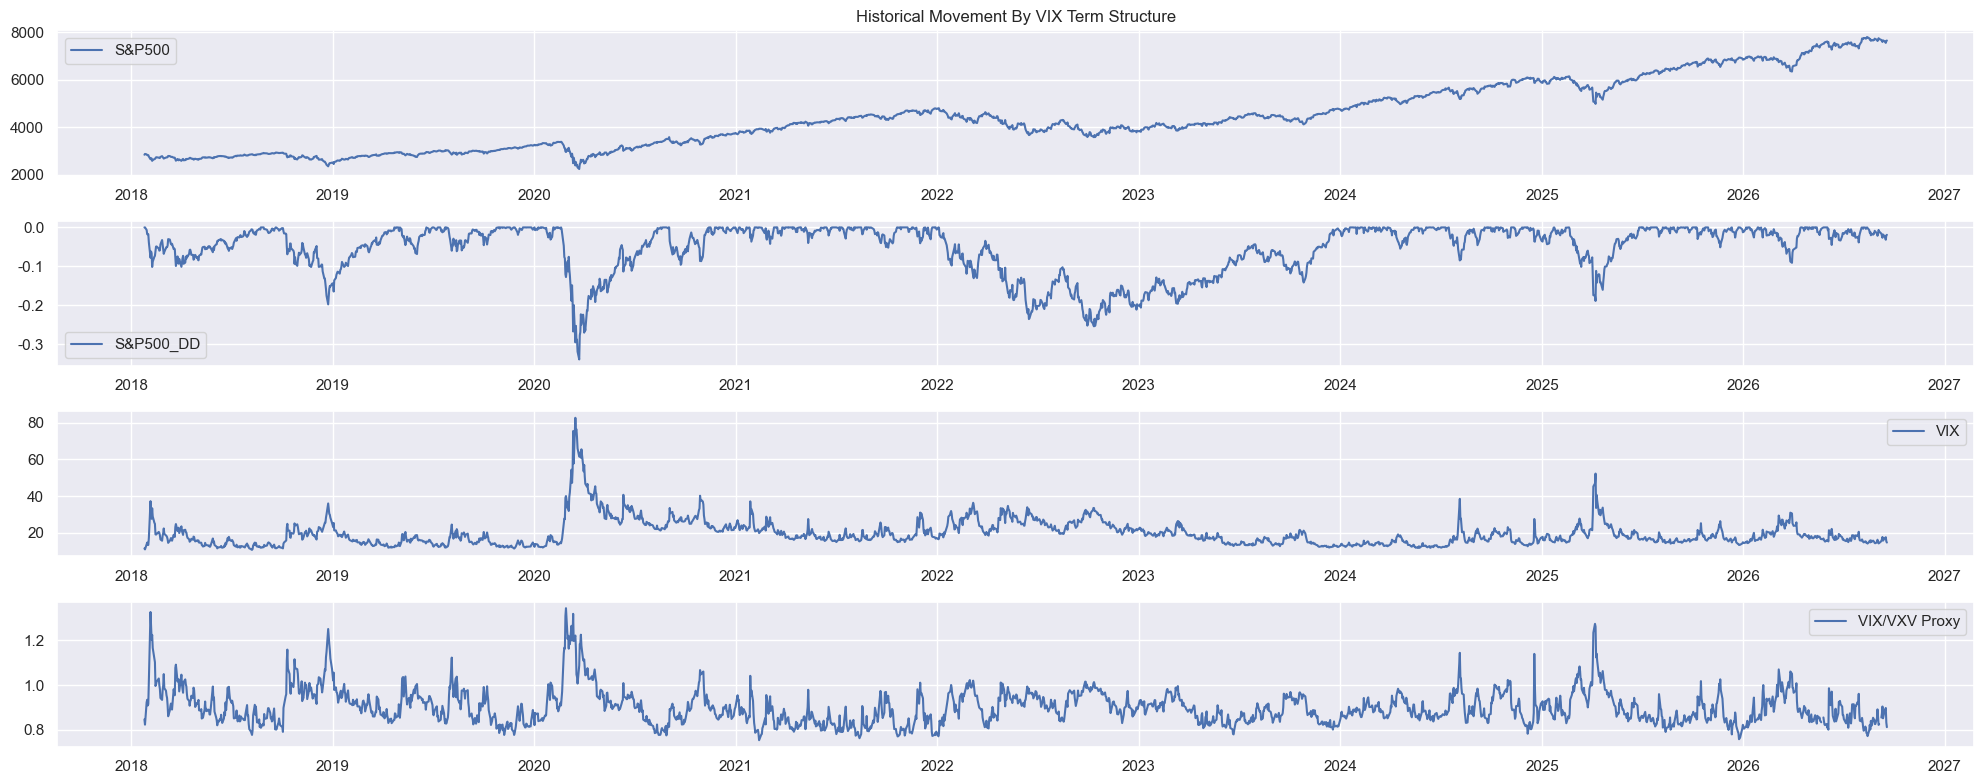

In [7]:
# 데이터 티커 : VIX, VIX선물 3개월물
tickers = ['^VIX', '^VIX3M']
# 데이터 다운로드 및 종가필터링
data = yf.download(tickers, start='2018-01-25', end='2026-09-21', auto_adjust=True)
data = data['Close']
data.columns = ['VIX', 'VIX3M']
# S&P500 가격 데이터
sp_500 = yf.download('^GSPC', start='2018-01-25', end='2026-09-21', auto_adjust=True)
sp_500 = sp_500['Close']
# VIX/VXV Ratio Proxy
vix = data['VIX']
vxv_proxy = data['VIX3M']
data['proxy_vvr'] = vix / vxv_proxy
proxy_vvr = data['proxy_vvr']

# S&P500 VIX와 VIX/VXV Proxy 시계열 시각화 
plt.figure(figsize=(20, 8))
plt.subplot(4,1,1)
plt.title('Historical Movement By VIX Term Structure')
plt.plot(sp_500, label='S&P500')
plt.legend()
plt.subplot(4,1,2)
plt.plot((sp_500 / sp_500.cummax()) - 1, label='S&P500_DD')
plt.legend()
plt.subplot(4,1,3)
plt.plot(vix, label='VIX')
plt.legend()
plt.subplot(4,1,4)
plt.plot(proxy_vvr, label='VIX/VXV Proxy')
plt.legend()
plt.tight_layout()
plt.show()




### VXX(VIX 근월 + 차월 롤오버 수익률을 지급하는 상장 채권 - ETN)의 과거 수익률 성과 분석

[*********************100%***********************]  1 of 1 completed


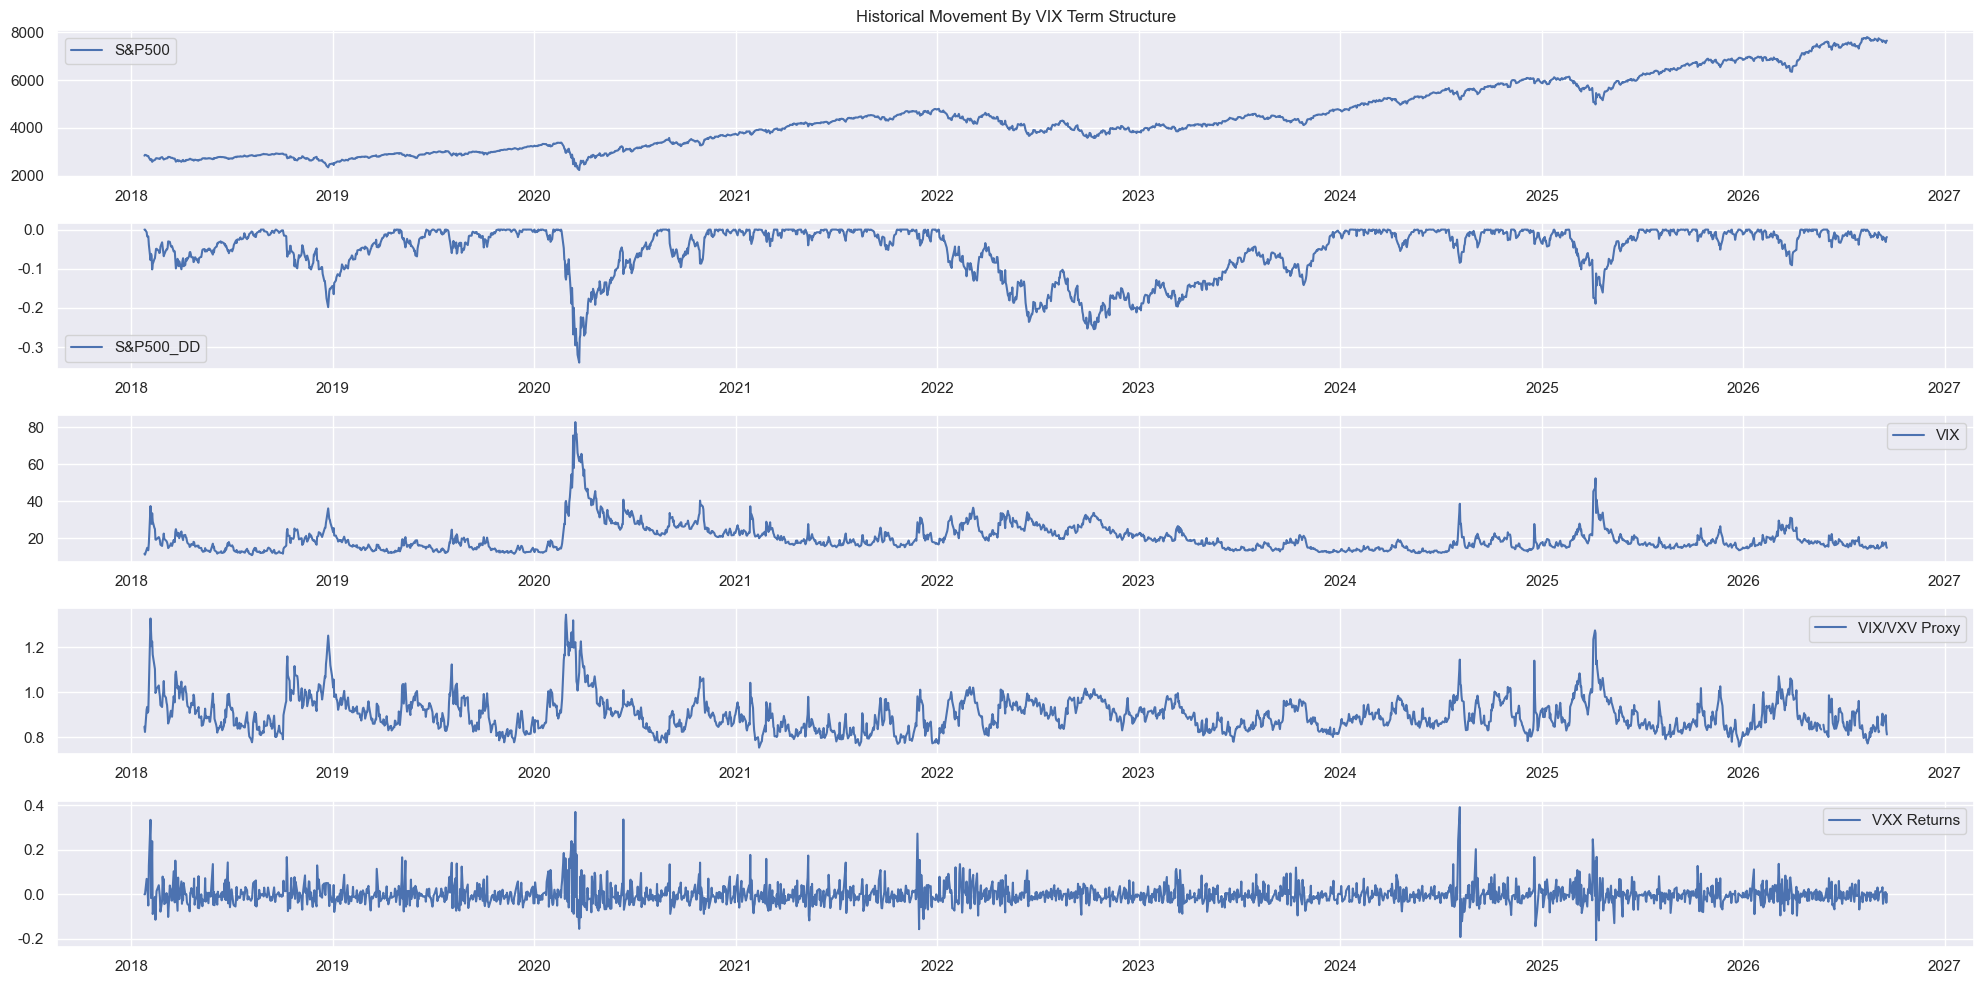

In [9]:
# VXX 가격 데이터 다운로드
vxx_ticker = 'VXX'
vxx = yf.download(vxx_ticker, start='2010-01-01', end='2026-09-21', auto_adjust=True)
vxx = vxx['Close']

# 수익률 시각화 
vxx_rets = vxx.pct_change().fillna(0)


# S&P500 VIX와 VIX/VXV Proxy 시계열 시각화 
plt.figure(figsize=(20, 10))
plt.subplot(5,1,1)
plt.title('Historical Movement By VIX Term Structure')
plt.plot(sp_500, label='S&P500')
plt.legend()
plt.subplot(5,1,2)
plt.plot((sp_500 / sp_500.cummax()) - 1, label='S&P500_DD')
plt.legend()
plt.subplot(5,1,3)
plt.plot(vix, label='VIX')
plt.legend()
plt.subplot(5,1,4)
plt.plot(proxy_vvr, label='VIX/VXV Proxy')
plt.legend()
plt.subplot(5,1,5)
plt.plot(vxx_rets, label='VXX Returns')
plt.legend()
plt.tight_layout()
plt.show()

### 변동성을 활용한 VXX Fat Tail Hedging 전략 간단 구현

In [ ]:
# 데이터 다운로드 
start_date = '2018-01-25'
tickers = ['^VIX', '^VIX3M']
data = yf.download(tickers, start=start_date, auto_adjust=True)
data = data['Close']
data.columns = ['VIX', 'VIX3M']
sp_500 = yf.download('^GSPC', start=start_date, auto_adjust=True)
sp_500 = sp_500['Close']
vix = data['VIX']
vxv_proxy = data['VIX3M']
data['proxy_vvr'] = vix / vxv_proxy
proxy_vvr = data['proxy_vvr']
vxx_ticker = 'VXX'
vxx = yf.download(vxx_ticker, start=start_date, auto_adjust=True)
vxx = vxx['Close']['VXX']
vxx_rets = vxx.pct_change().fillna(0)

# 시리즈 변환
vix = pd.Series(vix)
vxv_proxy = pd.Series(vxv_proxy)
proxy_vvr = pd.Series(proxy_vvr)
vxx = pd.Series(vxx)
vxx_rets = pd.Series(vxx_rets)

# 인덱스 통일
vix.index = pd.to_datetime(vix.index)
vxv_proxy.index = pd.to_datetime(vxv_proxy.index)
proxy_vvr.index = pd.to_datetime(proxy_vvr.index)
vxx.index = pd.to_datetime(vxx.index)
vxx_rets.index = pd.to_datetime(vxx_rets.index)

# VIX/VXV Ratio Proxy가 1이상인 비율
print('---------------------------------------')
print(f'VIX/VXV Ratio가 1 이상인 비율 : {np.round(((proxy_vvr >1).sum() / len(proxy_vvr)) * 100 ,2)} %') 


[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

---------------------------------------
VIX/VXV Ratio가 1 이상인 비율 : 8.45 %


 `vvr > 1.1 유지` -> `vvr < 1.1`     

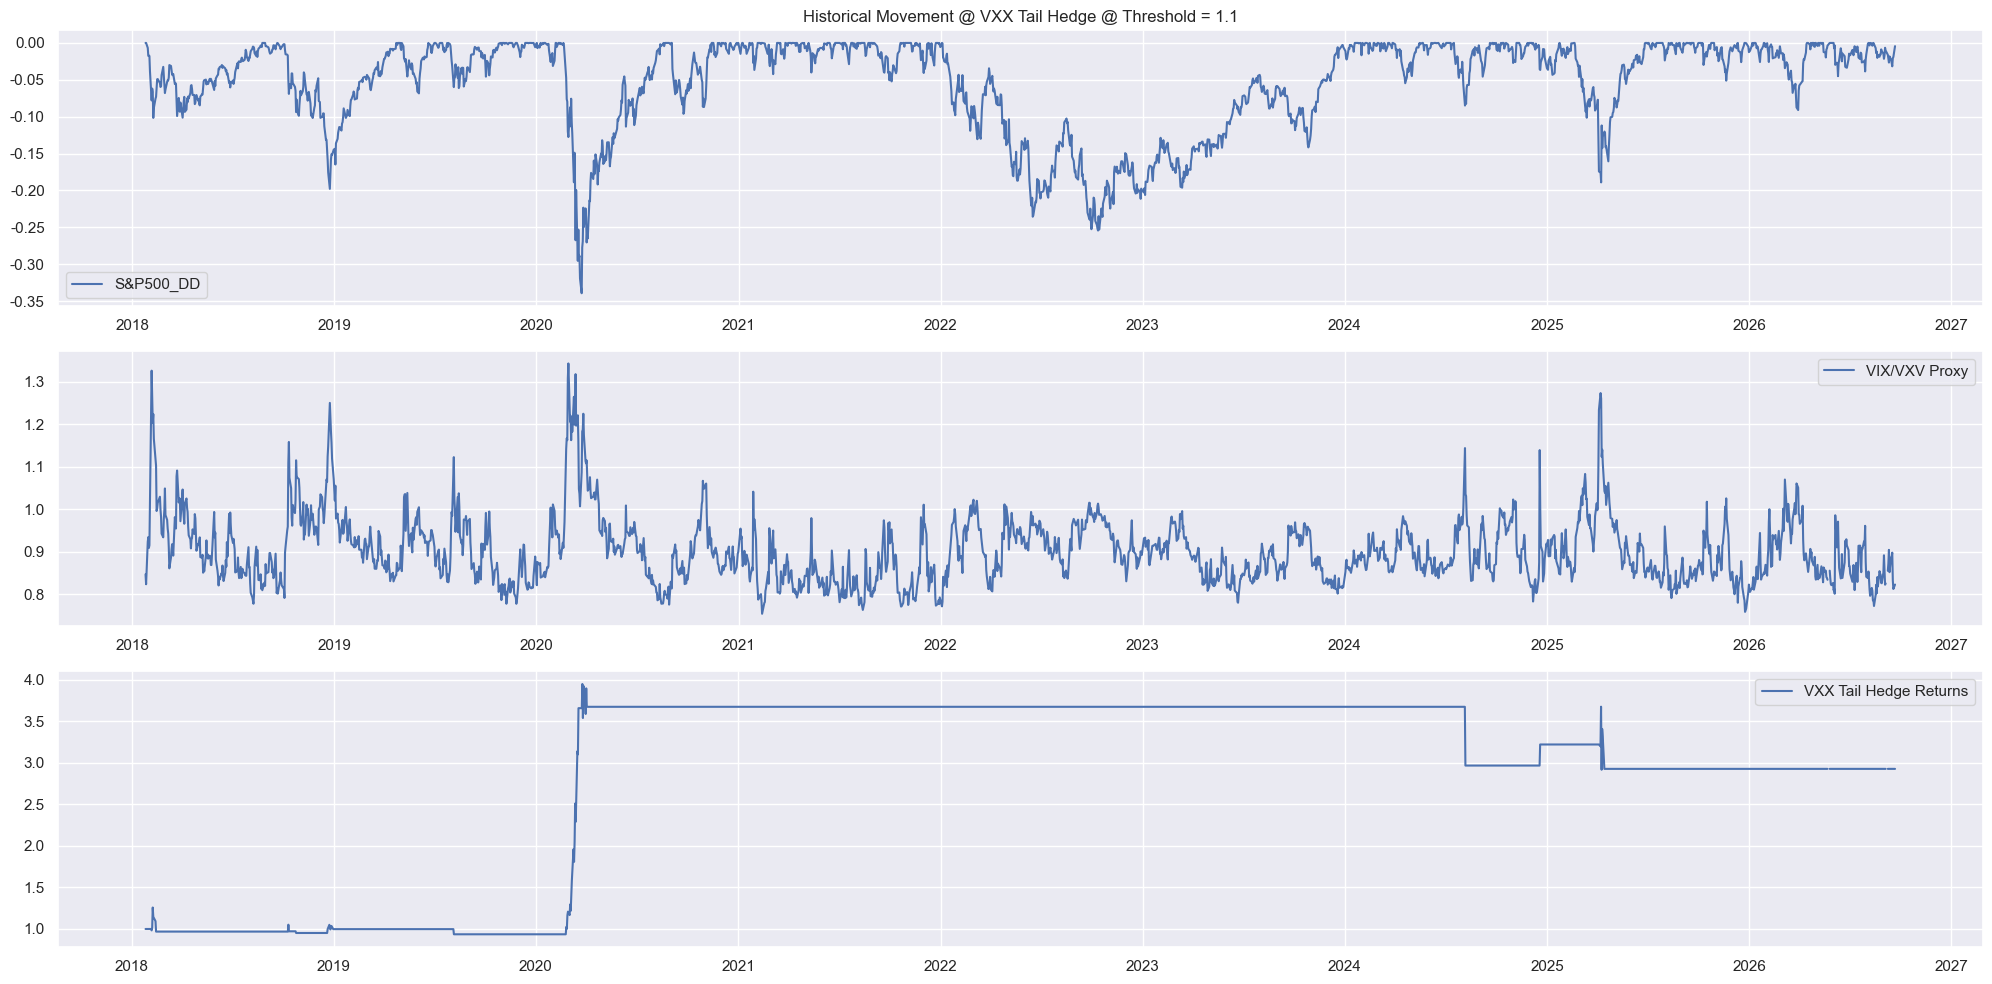

In [11]:
# 시그널 데이터 프레임 생성
signals = pd.Series(index=proxy_vvr.index)

# 시그널 임계값 설정
vvr_threshold = 1.1

# 임계값 이상일 때 Signal 1 , 미만이면 0
signals.loc[proxy_vvr > vvr_threshold] = 1
signals = signals.fillna(0)

# VXX Fat Tail Hedging 역사적 수익률
tail_hedge_rets = vxx_rets * signals.shift()

# VXX Fat Tail Hedging 역사적 누적 수익률
tail_hedge_cum_rets = ((1 + tail_hedge_rets).cumprod() - abs(signals.diff()) * 0.002 )

# S&P500 MDD, VIX/VXV Proxy, VXX Tail Hedge 성과 시각화  
plt.figure(figsize=(20, 10))
plt.subplot(3,1,1)
plt.title(f'Historical Movement @ VXX Tail Hedge @ Threshold = {vvr_threshold}')
plt.plot((sp_500 / sp_500.cummax()) - 1, label='S&P500_DD')
plt.legend()
plt.subplot(3,1,2)
plt.plot(proxy_vvr, label='VIX/VXV Proxy')
plt.legend()
plt.subplot(3,1,3)
plt.plot((1 + tail_hedge_rets).cumprod(), label='VXX Tail Hedge Returns')
plt.legend()
plt.tight_layout()
plt.show()

### SPY와 VXX Tail Risk Hedging 결합 전략 백테스팅

In [5]:
# SPY, VXX 티커정의 
ticker_univ = ['^VIX', '^VIX3M', 'VXX', 'SPY']

# 데이터 다운로드 
data_univ = yf.download(ticker_univ, start = '2018-01-25', auto_adjust=True)['Close'].dropna()


[*********************100%***********************]  4 of 4 completed


=== 백테스트 성과 요약 : 2018 ~ 현재 ===
단순 SPY 보유 CAGR: 13.97% | MDD: -33.72% | Sharpe: 0.78
커스텀 전략   CAGR: 15.35% | MDD: -18.25% | Sharpe: 1.20


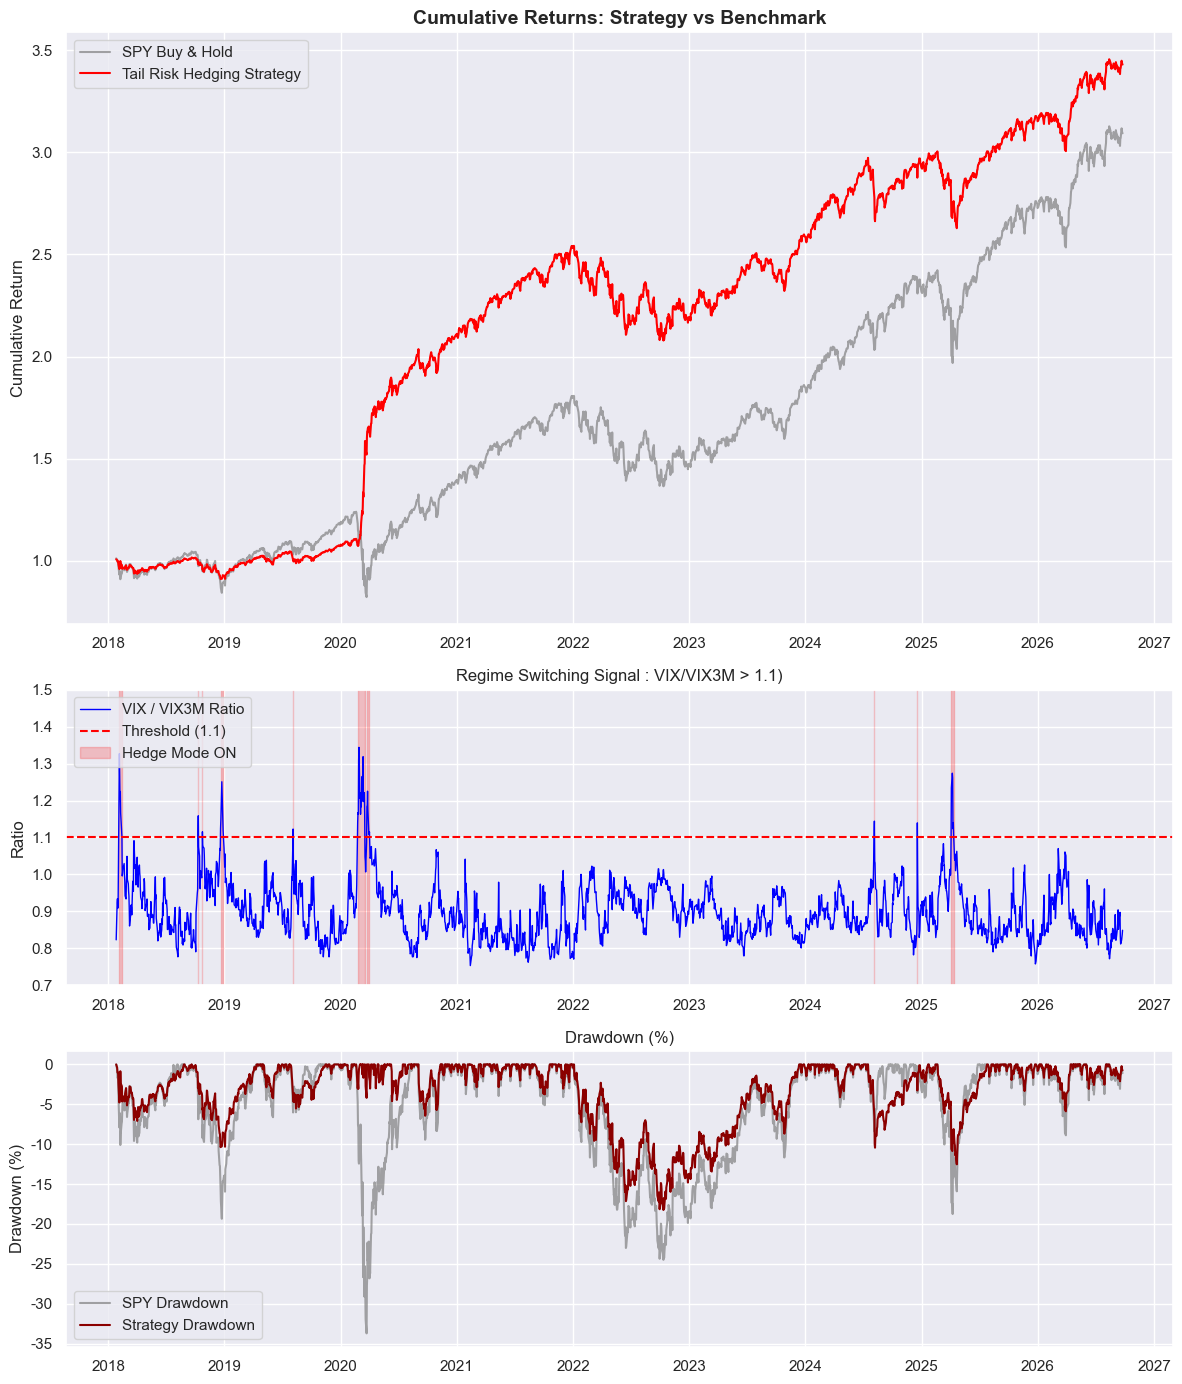

In [ ]:
df = data_univ.copy()

# 시그널 지표 계산
df['vix_ratio'] = df['^VIX'] / df['^VIX3M']

# 1 : 헤지, 0 : 평상 시
df['signal'] = (df['vix_ratio'] > 1.1).astype(int) 

# 자산별 일간 수익률 계산
df['spy_ret'] = df['SPY'].pct_change()
df['vxx_ret'] = df['VXX'].pct_change()
df = df.dropna() # 수익률 계산으로 발생한 첫 행 NaN 제거

# 매매 수수료 및 슬리피지 합산
fee_rate = 0.005  

# 저장용 리스트
port_rets = []

# 초기 포트폴리오 비중 (평상시 모드: SPY 60%, 현금 40%)
current_w_spy = 0.6
current_w_vxx = 0.0
current_w_cash = 0.4
prev_signal = 0 

for i in range(len(df)):
    spy_r = df['spy_ret'].iloc[i]
    vxx_r = df['vxx_ret'].iloc[i]
    
    # 선견편향 방지: 어제(T-1) 종가 기준 시그널을 확인하여 오늘(T) 수익률에 적용
    today_signal = df['signal'].iloc[i-1] if i > 0 else 0
        
    fee = 0.0 # 기본 비용 0
    
    # 시그널 변경 확인 (포트폴리오 국면 전환 -> 매매 발생)
    if today_signal != prev_signal:
        if today_signal == 1: # 평상시 -> 위기시 헤지 모드
            target_w_spy = 0.4
            target_w_vxx = 0.2
            target_w_cash = 0.4
        else:                 # 위기시 -> 평상시 관망 모드
            target_w_spy = 0.6
            target_w_vxx = 0.0
            target_w_cash = 0.4
            
        # 매매 대금 규모(Turnover) 계산 및 수수료 차감
        # 회전율 = (각 자산 비중 변동의 절대값 합) / 2
        turnover = (abs(target_w_spy - current_w_spy) + 
                    abs(target_w_vxx - current_w_vxx) + 
                    abs(target_w_cash - current_w_cash)) / 2
        fee = turnover * fee_rate
        
        # 목표 비중으로 업데이트
        current_w_spy = target_w_spy
        current_w_vxx = target_w_vxx
        current_w_cash = target_w_cash
        
        prev_signal = today_signal
        
    # 일간 포트폴리오 수익률 산출 (거래 비용 반영)
    port_ret = (current_w_spy * spy_r) + (current_w_vxx * vxx_r) - fee
    port_rets.append(port_ret)
    
    # 리밸런싱 규칙 4번 반영: 시그널 유지 구간에서는 비중이 수익률에 따라 표류(Drift)하도록 방치
    total_value = (current_w_spy * (1 + spy_r)) + (current_w_vxx * (1 + vxx_r)) + current_w_cash
    current_w_spy = current_w_spy * (1 + spy_r) / total_value
    current_w_vxx = current_w_vxx * (1 + vxx_r) / total_value
    current_w_cash = current_w_cash / total_value

df['strat_ret'] = port_rets

# 누적 수익률 계산
df['strat_cum'] = (1 + df['strat_ret']).cumprod()
df['spy_cum'] = (1 + df['spy_ret']).cumprod()


# 성과 지표 산출

def calculate_metrics(returns):
    cumulative = (1 + returns).cumprod()
    cagr = (cumulative.iloc[-1] ** (252 / len(returns))) - 1
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    
    roll_max = cumulative.cummax()
    dd = (cumulative - roll_max) / roll_max
    mdd = dd.min()
    return cagr, sharpe, mdd, dd

strat_cagr, strat_sharpe, strat_mdd, strat_dd = calculate_metrics(df['strat_ret'])
spy_cagr, spy_sharpe, spy_mdd, spy_dd = calculate_metrics(df['spy_ret'])

print(f'=== 백테스트 성과 요약 : 2018 ~ 현재 ===')
print(f'단순 SPY 보유 CAGR: {spy_cagr*100:.2f}% | MDD: {spy_mdd*100:.2f}% | Sharpe: {spy_sharpe:.2f}')
print(f'커스텀 전략   CAGR: {strat_cagr*100:.2f}% | MDD: {strat_mdd*100:.2f}% | Sharpe: {strat_sharpe:.2f}')


# 시각화 
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14), gridspec_kw={'height_ratios': [2, 1, 1]})

# 시각화 : 누적 수익률 
ax1.plot(df.index, df['spy_cum'], label='SPY Buy & Hold', color='gray', alpha=0.7)
ax1.plot(df.index, df['strat_cum'], label='Tail Risk Hedging Strategy', color='red', linewidth=1.5)
ax1.set_title('Cumulative Returns: Strategy vs Benchmark', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.legend(loc='upper left')

# 시각화 : VIX/VIX3M 시그널 및 헤지 국면 표시
ax2.plot(df.index, df['vix_ratio'], color='blue', linewidth=1, label='VIX / VIX3M Ratio')
ax2.axhline(1.1, color='red', linestyle='--', label='Threshold (1.1)')
ax2.fill_between(df.index, 0, 2, where=(df['signal']==1), color='red', alpha=0.2, label='Hedge Mode ON')
ax2.set_title('Regime Switching Signal : VIX/VIX3M > 1.1)', fontsize=12)
ax2.set_ylabel('Ratio')
ax2.set_ylim(0.7, 1.5)
ax2.legend(loc='upper left')

# 시각화 : MDD 
ax3.plot(df.index, spy_dd * 100, label='SPY Drawdown', color='gray', alpha=0.7)
ax3.plot(df.index, strat_dd * 100, label='Strategy Drawdown', color='darkred', linewidth=1.5)
ax3.set_title('Drawdown (%)', fontsize=12)
ax3.set_ylabel('Drawdown (%)')
ax3.legend(loc='lower left')

plt.tight_layout()
plt.show()